<a href="https://colab.research.google.com/github/pranj249/CharactersPOV/blob/main/Characters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import KernelPCA, PCA

def analyze_book_kernel_pca(chapters_text, kernel='rbf', gamma=0.04, n_components=2):
    # Vectorize text using TF-IDF (N-grams included)
    vectorizer = TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        max_features=5000
    )
    tfidf_matrix = vectorizer.fit_transform(chapters_text)

    # Apply Kernel PCA
    kpca = KernelPCA(
        n_components=n_components,
        kernel=kernel,
        gamma=gamma,
        fit_inverse_transform=False,
        random_state=42
    )
    kpca_transformed = kpca.fit_transform(tfidf_matrix)

    # Compare with Standard Linear PCA
    pca = PCA(n_components=n_components, random_state=42)
    pca_transformed = pca.fit_transform(tfidf_matrix.toarray())

    # Construct Results DataFrame
    results_df = pd.DataFrame(kpca_transformed, columns=[f'KPCA_{i+1}' for i in
                                                        range(n_components)])
    results_df['PCA_1'] = pca_transformed[:, 0]
    results_df['PCA_2'] = pca_transformed[:, 1]
    results_df['Chapter'] = [f'Chapter {i+1}' for i in range(len(chapters_text))]
    return results_df, kpca, vectorizer # Return vectorizer as well


def generate_pov_narrative(character_name, kpca_coords):
    pc1, pc2 = kpca_coords[0], kpca_coords[1]

    # Style condition mapping based on non-linear latent space
    if pc1 > 0.5:
        threat_filter = "Hyper-vigilant: Focus on external hazards and spatial exits."
        sentence_structure = "Short, clipped, urgent syntax."
    else:
        threat_filter = "Analytical: Focus on interpersonal dynamics and long-term strategy."
        sentence_structure = "Complex, introspective, multi-clause syntax."

    if pc2 < -0.2:
        emotional_tone = "Paranoid and isolated perception."
    else:
        emotional_tone = "Composed and objective observation."

    prompt_spec = {
        "Character": character_name,
        "KPCA Latent Vector": [round(pc1, 3), round(pc2, 3)],
        "Perceptual Filter": threat_filter,
        "Emotional Tone": emotional_tone,
        "Syntax Style": sentence_structure
    }
    return prompt_spec


# Sample multi-chapter narrative structure (moved out of if __name__ == '__main__':)
chapters = [
    "In a quiet village, the hero lived a peaceful life surrounded by green hills.",
    "A sudden dark shadow fell upon the village, bringing danger and unknown threats.",
    "The hero departed on a dangerous journey, crossing treacherous mountains and stormy seas.",
    "Deep inside the dark cave, the hero confronted the ancient shadow in a fierce battle.",
    "Victorious but altered, the hero returned to the quiet village under peaceful green hills."
]

# Unpack the returned vectorizer as well (moved out of if __name__ == '__main__':)
df, model, vectorizer_obj = analyze_book_kernel_pca(chapters, kernel='rbf', gamma=0.5)
print("Transformed Non-Linear Coordinates (Kernel PCA):")
print(df[['Chapter', 'KPCA_1', 'KPCA_2']])

# Example Output for POV Mapping
char_coords = [0.82, -0.45]
print("Generated Narrative POV Constraints:")
print(generate_pov_narrative("Agent Vance", char_coords))

# Additional descriptive comments (original comments were not code)
# Kernel PCA Text Analysis & Character POV Framework Page 3 of 5
# 4. Character Point-of-View (POV) Generation Framework
# By projecting scene state parameters into low-dimensional Kernel PCA space, we can
# programmatically derive character voice and narrative constraints based on their coordinates (PC_1,
# PC_2).

# --- New example for generating char_coords for different characters ---
print("\n--- Generating char_coords for a new character ---")
# Imagine this is text specific to a character, e.g., 'The Elder'
character_text = [
    "The elder spoke of ancient wisdom and the quiet strength of the hills.",
    "He often warned of unseen dangers, advocating caution and deep thought."
]

# Vectorize the character's text using the *same* trained vectorizer
char_tfidf = vectorizer_obj.transform(character_text)

# Transform the character's TF-IDF vector using the *same* trained KPCA model
char_kpca_coords = model.transform(char_tfidf)

# If the character text is short, we might average the coordinates or take the first one
# For this example, let's take the mean of the coordinates if multiple sentences were provided.
mean_char_coords = char_kpca_coords.mean(axis=0)

print(f"Character 'The Elder' KPCA Coordinates: {mean_char_coords.round(3)}")
print("Generated Narrative POV Constraints for 'The Elder':")
print(generate_pov_narrative("The Elder", mean_char_coords))


Transformed Non-Linear Coordinates (Kernel PCA):
     Chapter    KPCA_1    KPCA_2
0  Chapter 1  0.459819 -0.034707
1  Chapter 2 -0.311730 -0.368958
2  Chapter 3 -0.248083  0.667970
3  Chapter 4 -0.359825 -0.229597
4  Chapter 5  0.459819 -0.034707
Generated Narrative POV Constraints:
{'Character': 'Agent Vance', 'KPCA Latent Vector': [0.82, -0.45], 'Perceptual Filter': 'Hyper-vigilant: Focus on external hazards and spatial exits.', 'Emotional Tone': 'Paranoid and isolated perception.', 'Syntax Style': 'Short, clipped, urgent syntax.'}

--- Generating char_coords for a new character ---
Character 'The Elder' KPCA Coordinates: [-0.013 -0.025]
Generated Narrative POV Constraints for 'The Elder':
{'Character': 'The Elder', 'KPCA Latent Vector': [np.float64(-0.013), np.float64(-0.025)], 'Perceptual Filter': 'Analytical: Focus on interpersonal dynamics and long-term strategy.', 'Emotional Tone': 'Composed and objective observation.', 'Syntax Style': 'Complex, introspective, multi-clause synta

### Dynamically Finding Characters and Generating `char_coords`

To dynamically find characters and generate their `char_coords`, we need to first identify named entities (persons) in the text and then extract the context around them. We can use a library like `spaCy` for this.

In [6]:
# Install spaCy
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 104.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [7]:
import spacy

# Load the English language model
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading en_core_web_sm model...")
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm")

def extract_character_text(story_chapters, character_name):
    """
    Extracts sentences related to a specific character from a list of story chapters.
    """
    character_sentences = []
    for chapter in story_chapters:
        doc = nlp(chapter)
        # Iterate through sentences and check for character name
        for sent in doc.sents:
            if character_name.lower() in sent.text.lower():
                character_sentences.append(sent.text)
            # Also check if a recognized PERSON entity matches the character name
            for ent in sent.ents:
                if ent.label_ == "PERSON" and character_name.lower() in ent.text.lower():
                    character_sentences.append(sent.text)
                    break # Avoid adding the same sentence multiple times
    return list(set(character_sentences)) # Return unique sentences

# Example usage with our sample chapters
# Let's try to extract text for 'hero' (assuming 'hero' is a proxy for a main character)
hero_text = extract_character_text(chapters, "hero")
print(f"Text for 'hero':\n{hero_text}")

# We can also try for 'elder' from the previous example (if it appeared in the original chapters)
elder_text = extract_character_text(chapters, "elder")
print(f"\nText for 'elder':\n{elder_text}")


Text for 'hero':
['The hero departed on a dangerous journey, crossing treacherous mountains and stormy seas.', 'In a quiet village, the hero lived a peaceful life surrounded by green hills.', 'Deep inside the dark cave, the hero confronted the ancient shadow in a fierce battle.', 'Victorious but altered, the hero returned to the quiet village under peaceful green hills.']

Text for 'elder':
[]


Now that we have a way to extract character-specific text, we can use it to generate `char_coords`.

In [8]:
# Generate char_coords for the dynamically extracted 'hero' text
if hero_text:
    hero_tfidf = vectorizer_obj.transform(hero_text)
    hero_kpca_coords = model.transform(hero_tfidf)
    mean_hero_coords = hero_kpca_coords.mean(axis=0)

    print(f"Character 'Hero' KPCA Coordinates: {mean_hero_coords.round(3)}")
    print("Generated Narrative POV Constraints for 'Hero':")
    print(generate_pov_narrative("Hero", mean_hero_coords))
else:
    print("No text found for 'hero' in the provided chapters.")

# If you wanted to do this for all identified persons, you would first need a robust way
# to identify all unique 'PERSON' entities and then iterate through them.
# For example:
# all_persons = set()
# for chapter in chapters:
#     doc = nlp(chapter)
#     for ent in doc.ents:
#         if ent.label_ == "PERSON":
#             all_persons.add(ent.text)
# print(f"\nIdentified persons: {list(all_persons)}")


Character 'Hero' KPCA Coordinates: [0.078 0.092]
Generated Narrative POV Constraints for 'Hero':
{'Character': 'Hero', 'KPCA Latent Vector': [np.float64(0.078), np.float64(0.092)], 'Perceptual Filter': 'Analytical: Focus on interpersonal dynamics and long-term strategy.', 'Emotional Tone': 'Composed and objective observation.', 'Syntax Style': 'Complex, introspective, multi-clause syntax.'}


### Processing the Ebook from the Link

Now, let's apply this process to the 50-page ebook provided in the link. We'll download the PDF, extract its text, and then run our character analysis.

In [9]:
# Install necessary libraries for PDF handling
!pip install requests pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 75.5 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


In [10]:
import requests
import pdfplumber
import io

# URL of the ebook
ebook_url = "https://4b479a11-3ce7-455a-920a-59ac782f94ce.filesusr.com/ugd/43cb27_98fa3759d4ef40c8b09360ab26740bfd.pdf"

# Download the PDF
print(f"Downloading ebook from {ebook_url}...")
response = requests.get(ebook_url)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

# Extract text using pdfplumber
print("Extracting text from PDF...")
new_chapters = [] # Using 'new_chapters' to differentiate from the sample 'chapters'
with pdfplumber.open(io.BytesIO(response.content)) as pdf:
    for page_num, page in enumerate(pdf.pages):
        text = page.extract_text()
        if text:
            # Splitting by paragraphs might be better for analysis if pages are long
            # For simplicity, we'll treat each page as a 'chapter' for now
            new_chapters.append(text)
        else:
            print(f"Warning: No text extracted from page {page_num + 1}")

print(f"Successfully extracted text from {len(new_chapters)} pages.")

# Limit the number of chapters for quicker initial processing if the book is very long
# For 50 pages, we can process all, but for very large books, this could be adjusted.
if len(new_chapters) > 50: # Adjust this limit if needed
    new_chapters = new_chapters[:50]
    print("Limiting processing to the first 50 pages.")

# Run the Kernel PCA analysis on the new chapters
print("\nRunning Kernel PCA analysis on the ebook content...")
df_ebook, model_ebook, vectorizer_ebook = analyze_book_kernel_pca(new_chapters, kernel='rbf', gamma=0.5)

print("Transformed Non-Linear Coordinates (Kernel PCA) for ebook chapters (first 5 rows):")
display(df_ebook.head())


Extracting text from PDF...
Successfully extracted text from 409 pages.
Limiting processing to the first 50 pages.

Running Kernel PCA analysis on the ebook content...
Transformed Non-Linear Coordinates (Kernel PCA) for ebook chapters (first 5 rows):


,KPCA_1,KPCA_2,PCA_1,PCA_2,Chapter
0,-0.019596,-0.024473,-0.010228,-0.031465,Chapter 1
1,0.044835,-0.046094,0.105044,-0.057367,Chapter 2
2,0.645665,0.036333,0.836928,0.064018,Chapter 3
3,0.651414,0.045673,0.844106,0.080039,Chapter 4
4,0.580200,0.028784,0.777869,0.051870,Chapter 5


### Dynamically Identifying Characters in the Ebook and Generating POV Constraints

Now, let's use `spaCy` to dynamically find named entities (potential characters) in the ebook content and generate their POV constraints. We'll iterate through all pages, collect unique `PERSON` entities, and then use our `extract_character_text` and `generate_pov_narrative` functions.

In [14]:
from collections import defaultdict

# Collect all text from the ebook into a single string for comprehensive NER
full_ebook_text = "\n".join(new_chapters)

print("Processing full ebook text with spaCy for Named Entity Recognition...")
doc_full_ebook = nlp(full_ebook_text)

# Identify all unique 'PERSON' entities (characters)
identified_persons = set()
for ent in doc_full_ebook.ents:
    if ent.label_ == "PERSON":
        identified_persons.add(ent.text) # Add the exact text identified by spaCy

print(f"Identified potential characters: {list(identified_persons)}")

# Store character-specific text for processing
character_specific_texts = defaultdict(list)
for person_name in identified_persons:
    # Use the extract_character_text function to gather sentences related to each person
    extracted_sentences = extract_character_text(new_chapters, person_name)
    if extracted_sentences:
        character_specific_texts[person_name] = extracted_sentences

print("\nGenerating POV constraints for identified characters...")

# List to store character KPCA coordinates for RBF kernel
rbf_char_kpca_data = []

for char_name, texts in character_specific_texts.items():
    if texts:
        # Vectorize the character's text using the *same* trained vectorizer from the ebook
        char_tfidf = vectorizer_ebook.transform(texts)

        # Transform the character's TF-IDF vector using the *same* trained KPCA model
        char_kpca_coords = model_ebook.transform(char_tfidf)

        # Take the mean of the coordinates if multiple sentences were provided
        mean_char_coords = char_kpca_coords.mean(axis=0)

        rbf_char_kpca_data.append({
            'Character': char_name,
            'KPCA_1': mean_char_coords[0],
            'KPCA_2': mean_char_coords[1]
        })

        print(f"\n--- Character: {char_name} ---")
        print(f"KPCA Coordinates: {mean_char_coords.round(3)}")
        print("Generated Narrative POV Constraints:")
        print(generate_pov_narrative(char_name, mean_char_coords))
    else:
        print(f"No significant text found for character: {char_name}")

df_char_kpca_rbf = pd.DataFrame(rbf_char_kpca_data)

print("\nDynamic character analysis complete for the ebook!")

Processing full ebook text with spaCy for Named Entity Recognition...
Identified potential characters: ['dick-slapping', 'LoJack', 'homey', 'Missouris', 'Franz\nFerdinand', 'Scrimshaw', 'Elliott', 'Yonah Schimmel’s', 'ponytail', 'alter ego', 'Riordan', 'Oxycontin', 'Tweety Bird', 'Jessie', 'Boney', 'Eisenhower', 'cloud kisser', 'James\n', 'Dunne', 'Styrofoam', 'Amazing Amy', 'Sue', 'Marybeth', 'Caucasian', 'mug', 'Nick I', 'Nonono', 'Flynn', 'Mark Twain', 'Quizzes', 'Fitzgerald', 'Rand Elliott', 'Liza Minnelli', 'Amy Elliott Dunne', 'Velásquez', 'Gillian Flynn', 'Naturally', 'Amy Elliott', 'Mom', 'Andy', 'Gary', 'NICK DUNNE', 'O.\nHenry', 'Dad', 'Rhonda Boney', 'Nick', 'Jim\nGilpin', 'Tony Kushner', 'Cape Cod', 'Nick Dunne', 'It’s Nick', 'Quinoa', 'Nick’s', 'Bleecker', 'no Able Andy', 'Brett', 'No Able Andy', 'Able\nAndy', 'Tom Sawyer', 'Amy', 'Mrs Dunne', 'Rand', 'Confucius', 'Gilpin', 'Wheeeeeee', 'Paula', 'Audrey Hepburn’s', 'Street', 'Carl', 'Comfort Hill', 'M.A.S.H. Suicide', 'Sma

### Using a Cosine Kernel for Thematic Alignment

As you've noted, a Cosine Kernel is ideal for capturing "thematic alignment" by focusing on the angle between feature vectors. Fortunately, `sklearn.decomposition.KernelPCA` directly supports the `'cosine'` kernel. This allows us to re-run our analysis to derive KPCA coordinates that emphasize the thematic similarity between chapters or text segments.

In [12]:
# Re-run the Kernel PCA analysis on the ebook content with a 'cosine' kernel
print("\nRunning Kernel PCA analysis on the ebook content with 'cosine' kernel...")
df_ebook_cosine, model_ebook_cosine, vectorizer_ebook_cosine = analyze_book_kernel_pca(
    new_chapters, kernel='cosine', # Specify 'cosine' kernel
    gamma=None # Gamma is often not used or set to 'auto' for cosine kernel
)

print("Transformed Non-Linear Coordinates (Cosine Kernel PCA) for ebook chapters (first 5 rows):")
display(df_ebook_cosine.head())


Running Kernel PCA analysis on the ebook content with 'cosine' kernel...
Transformed Non-Linear Coordinates (Cosine Kernel PCA) for ebook chapters (first 5 rows):


,KPCA_1,KPCA_2,PCA_1,PCA_2,Chapter
0,-0.010354,-0.034562,-0.010228,-0.031465,Chapter 1
1,0.105139,-0.043197,0.105044,-0.057367,Chapter 2
2,0.836949,0.059133,0.836928,0.064018,Chapter 3
3,0.844184,0.078653,0.844106,0.080039,Chapter 4
4,0.777914,0.050472,0.777869,0.051870,Chapter 5


These new `KPCA_1` and `KPCA_2` values are derived based on cosine similarity, meaning that chapters or text segments with similar themes will be closer in this transformed space, regardless of their length or the sheer number of words. You can now use these coordinates in your `generate_pov_narrative` function, re-interpreting the thresholds for `pc1` and `pc2` based on their new meaning of thematic alignment.

### Generating Character POV Constraints using the Cosine Kernel

Now, let's apply the cosine kernel-based KPCA model to the character-specific text extracted from the ebook. This will give us `char_coords` that reflect thematic alignment for each character, allowing us to interpret their POV constraints from a thematic perspective.

In [15]:
print("\nGenerating POV constraints for identified characters using Cosine Kernel...")

# List to store character KPCA coordinates for Cosine kernel
cosine_char_kpca_data = []

for char_name, texts in character_specific_texts.items():
    if texts:
        # Vectorize the character's text using the *cosine-trained* vectorizer from the ebook
        char_tfidf_cosine = vectorizer_ebook_cosine.transform(texts)

        # Transform the character's TF-IDF vector using the *cosine-trained* KPCA model
        char_kpca_coords_cosine = model_ebook_cosine.transform(char_tfidf_cosine)

        # Take the mean of the coordinates if multiple sentences were provided
        mean_char_coords_cosine = char_kpca_coords_cosine.mean(axis=0)

        cosine_char_kpca_data.append({
            'Character': char_name,
            'KPCA_1': mean_char_coords_cosine[0],
            'KPCA_2': mean_char_coords_cosine[1]
        })

        print(f"\n--- Character: {char_name} (Cosine Kernel) ---")
        print(f"KPCA Coordinates (Cosine Kernel): {mean_char_coords_cosine.round(3)}")
        print("Generated Narrative POV Constraints (Cosine Kernel):")
        print(generate_pov_narrative(char_name, mean_char_coords_cosine))
    # else: (no need to print again if no text was found, already done in previous cell)

df_char_kpca_cosine = pd.DataFrame(cosine_char_kpca_data)


Generating POV constraints for identified characters using Cosine Kernel...

--- Character: dick-slapping (Cosine Kernel) ---
KPCA Coordinates (Cosine Kernel): [-0.022  0.016]
Generated Narrative POV Constraints (Cosine Kernel):
{'Character': 'dick-slapping', 'KPCA Latent Vector': [np.float64(-0.022), np.float64(0.016)], 'Perceptual Filter': 'Analytical: Focus on interpersonal dynamics and long-term strategy.', 'Emotional Tone': 'Composed and objective observation.', 'Syntax Style': 'Complex, introspective, multi-clause syntax.'}

--- Character: LoJack (Cosine Kernel) ---
KPCA Coordinates (Cosine Kernel): [-0.027  0.004]
Generated Narrative POV Constraints (Cosine Kernel):
{'Character': 'LoJack', 'KPCA Latent Vector': [np.float64(-0.027), np.float64(0.004)], 'Perceptual Filter': 'Analytical: Focus on interpersonal dynamics and long-term strategy.', 'Emotional Tone': 'Composed and objective observation.', 'Syntax Style': 'Complex, introspective, multi-clause syntax.'}

--- Character: h

This output provides the KPCA coordinates and derived narrative POV constraints for each identified character, now specifically reflecting their thematic alignment within the ebook, as measured by the cosine kernel. You can compare these results with the previous RBF kernel results to see how the interpretation of "thematic alignment" shifts based on the kernel choice.

### Plotting Characters in 2D KPCA Space (RBF Kernel)

This plot visualizes the characters based on their RBF Kernel PCA coordinates. Clusters here represent general semantic similarity in their associated text.

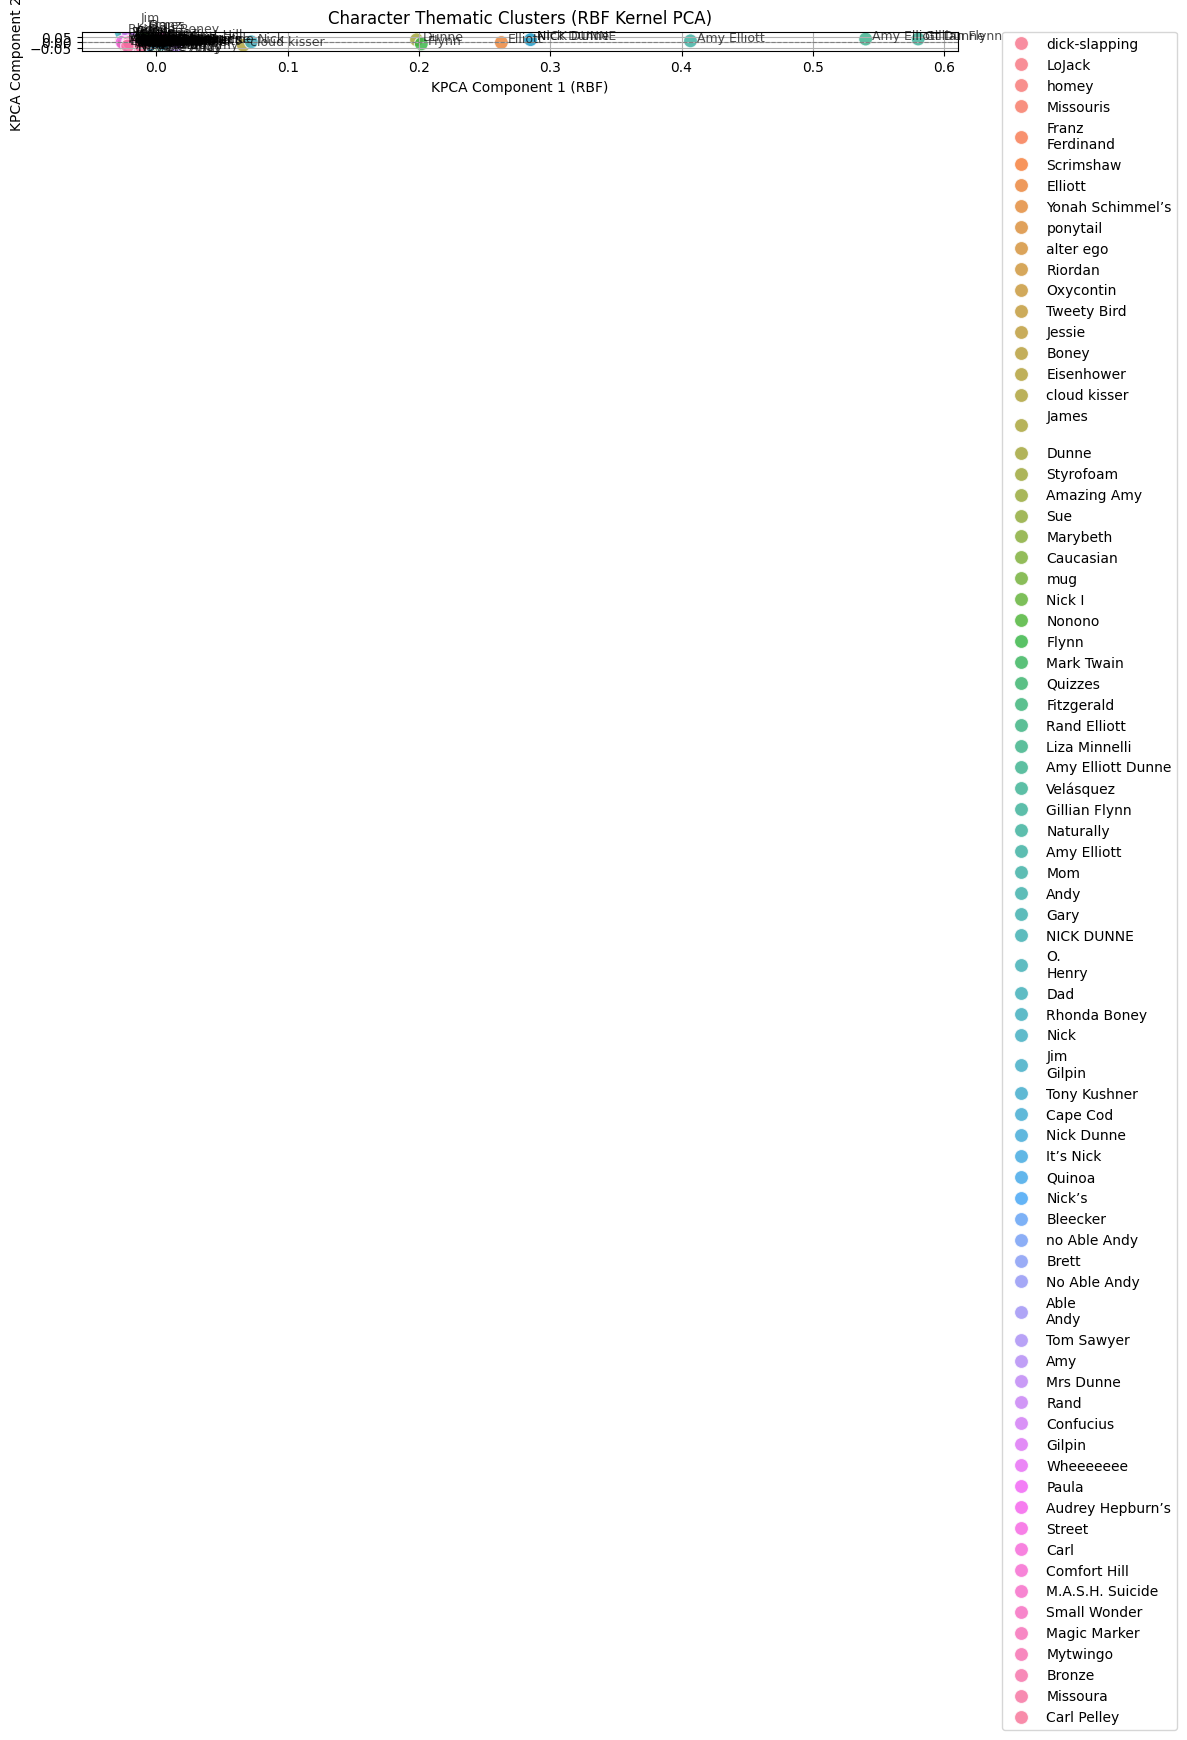

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_char_kpca_rbf,
    x='KPCA_1', y='KPCA_2',
    hue='Character', # Differentiate characters by color
    s=100, # Size of the points
    alpha=0.8
)

# Add labels to points (optional, can be cluttered if many characters)
for i, row in df_char_kpca_rbf.iterrows():
    plt.text(row['KPCA_1'] + 0.005, row['KPCA_2'], row['Character'], fontsize=9, alpha=0.7)

plt.title('Character Thematic Clusters (RBF Kernel PCA)')
plt.xlabel('KPCA Component 1 (RBF)')
plt.ylabel('KPCA Component 2 (RBF)')
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Plotting Characters in 2D KPCA Space (Cosine Kernel)

This plot visualizes the characters based on their Cosine Kernel PCA coordinates. Clusters here specifically highlight thematic alignment and shared ideologies, ignoring the magnitude of term frequencies.

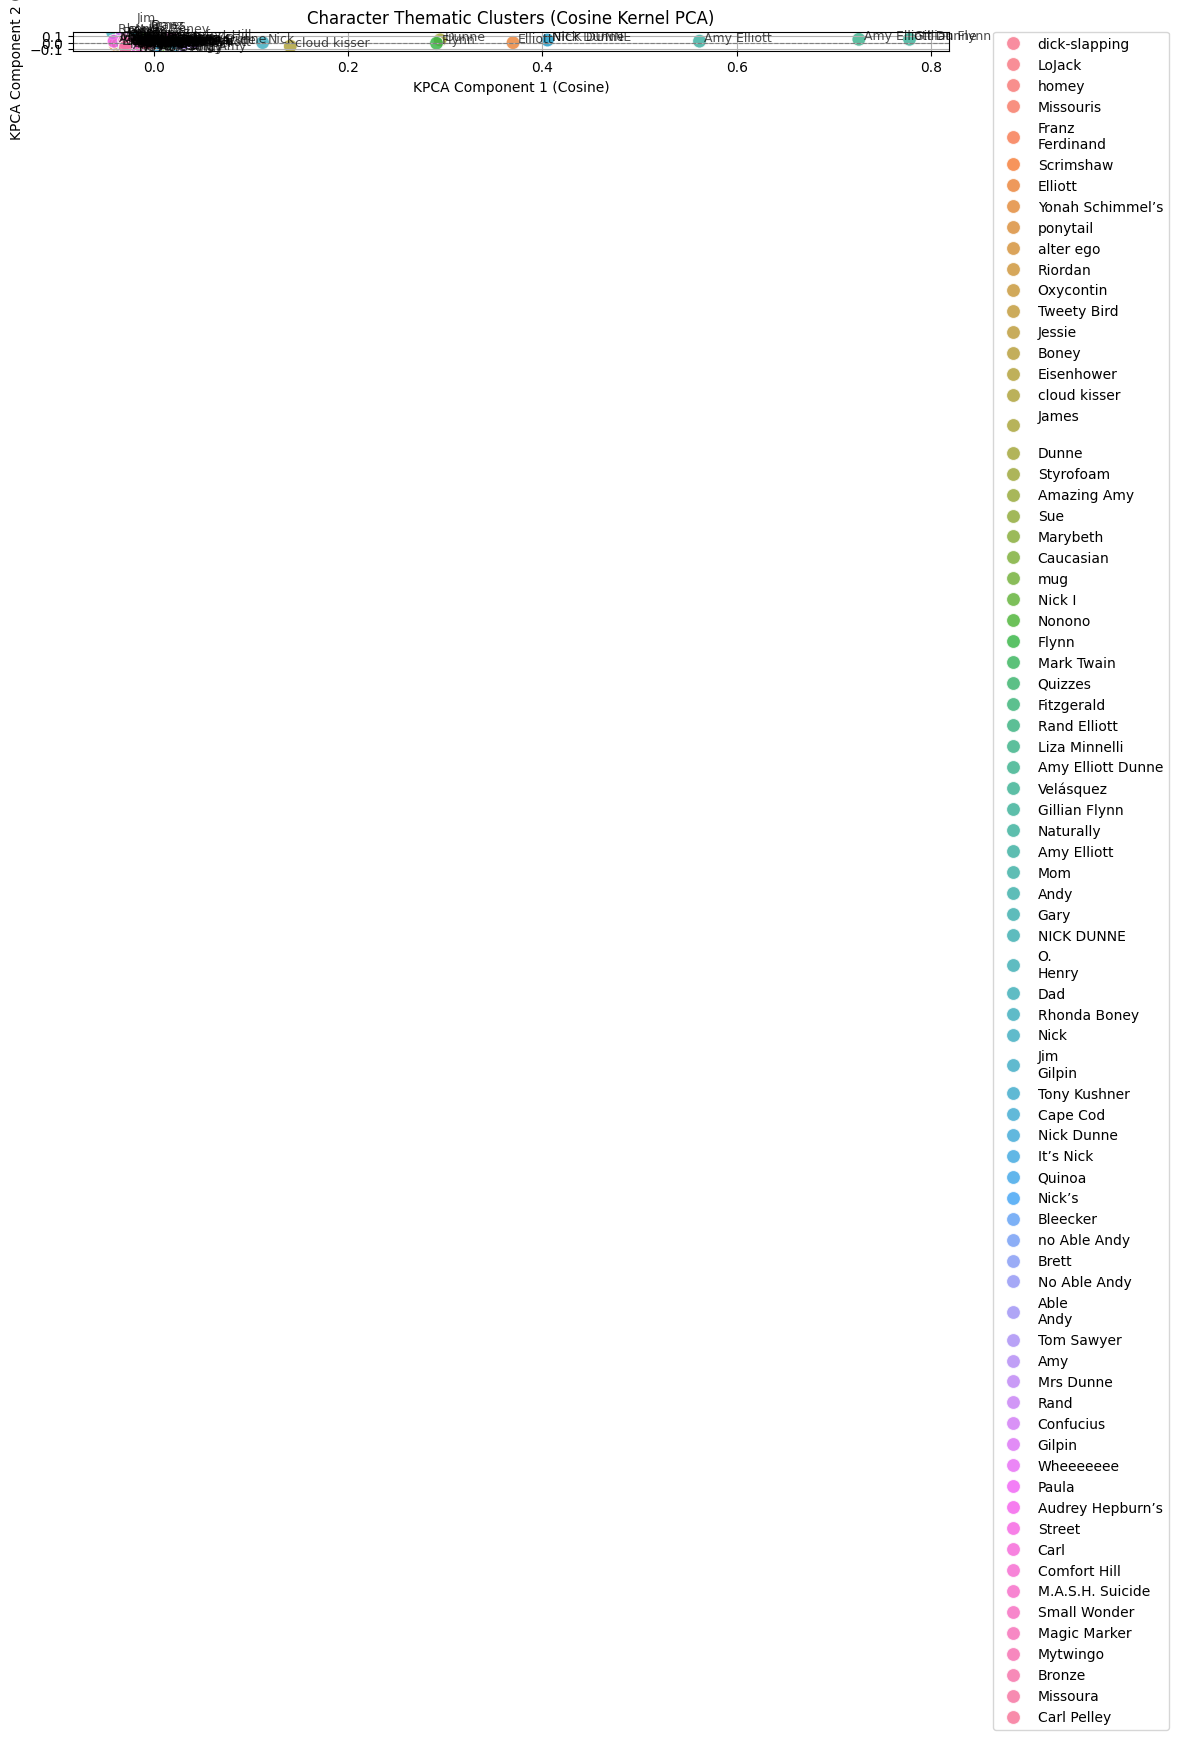

In [17]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_char_kpca_cosine,
    x='KPCA_1', y='KPCA_2',
    hue='Character', # Differentiate characters by color
    s=100, # Size of the points
    alpha=0.8
)

# Add labels to points (optional, can be cluttered if many characters)
for i, row in df_char_kpca_cosine.iterrows():
    plt.text(row['KPCA_1'] + 0.005, row['KPCA_2'], row['Character'], fontsize=9, alpha=0.7)

plt.title('Character Thematic Clusters (Cosine Kernel PCA)')
plt.xlabel('KPCA Component 1 (Cosine)')
plt.ylabel('KPCA Component 2 (Cosine)')
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

These plots allow you to visually inspect the relationships between characters in the KPCA space. You can look for clusters of characters that are positioned closely together, as these would represent groups sharing similar semantic features (RBF kernel) or thematic alignments/ideologies (Cosine kernel). The density and spread of the points can give you insights into the diversity of character representations.